<a href="https://colab.research.google.com/github/aaqhilahamed2004-ops/QiskitCourses/blob/main/Quantum_Teleportation_Protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.7 MB/s eta 0:00:00


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.quantum_info import Statevector, Operator
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
import numpy as np

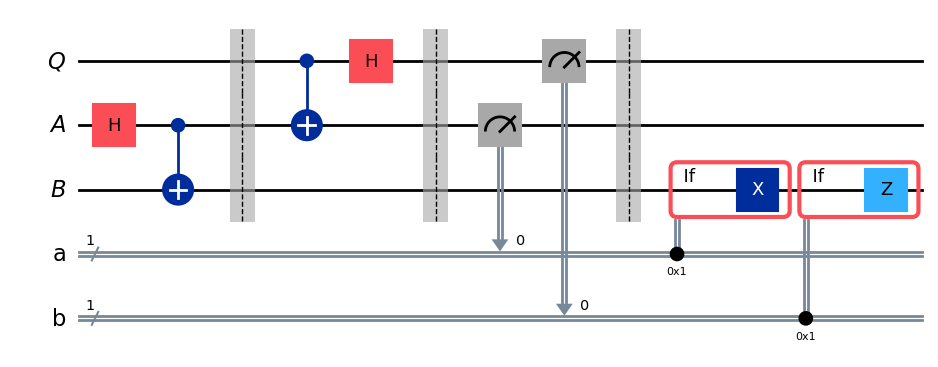

In [ ]:
#Defining Quantum and Classical Registers
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a     = ClassicalRegister(1, "a")
b     = ClassicalRegister(1, "b")

#Making a circuit with required registers
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

#Preparing Bell State between Alice and Bob
#Prepare e-bit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

#Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

#Alice measures and send Classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

#Bob uses Classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
  protocol.x(ebit1)

with protocol.if_test((b, 1)):
  protocol.z(ebit1)

display(protocol.draw(output="mpl"))

In [ ]:
random_gate = UGate(
    theta = random.random()*2*pi,
    phi = random.random()*2*pi,
    lam = random.random()*2*pi)
display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

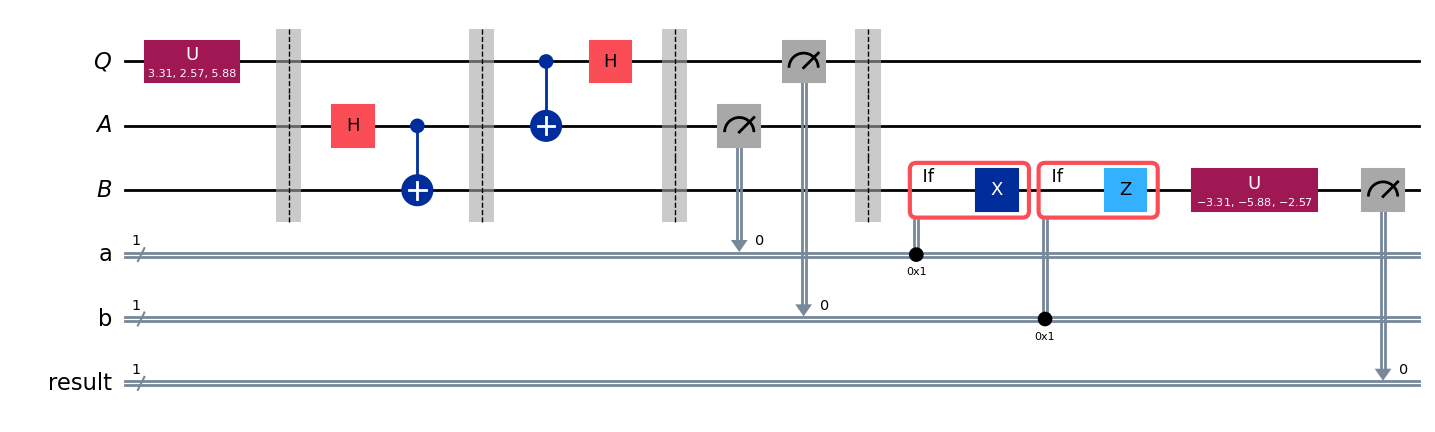

In [ ]:
#Create a new circuit including the same bits and qubits used in the
#teleportation protocol

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

#Start with the randomly selected gate on Q
test.append(random_gate, qubit)
test.barrier()

#Append the entire teleportation protocol from above
test = test.compose(protocol)
test.barrier

#apply the inverse of the random unitary to B and measure

test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw(output="mpl"))